# 添加记忆

聊天机器人可以使用工具来回答用户问题，但它**不记得之前交互的上下文**。这限制了它进行连贯多轮对话的能力。

LangGraph 通过持久性检查点解决了这个问题。如果您在编译图时提供一个checkpointer，并在调用图时提供一个thread_id，LangGraph 会在每一步之后自动保存状态。当您使用相同的thread_id再次调用图时，图会加载其保存的状态，允许聊天机器人从上次中断的地方继续。

我们稍后会看到，检查点比简单的聊天记忆功能强大得多——它允许您随时保存和恢复复杂状态，用于错误恢复、人工干预工作流、时间旅行交互等

In [7]:
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
import os
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode, tools_condition

# 加载 .env 文件
load_dotenv(override=True)


os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_PROJECT"] = "langgraph_learnning"
os.environ["LANGSMITH_ENDPOINT"] = "https://aws.api.smith.langchain.com"

############### 创建 MemorySaver 检查点 ###############
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
######################################################


class State(TypedDict):
    messages: Annotated[list, add_messages]
    
graph_builder = StateGraph(State)

search_tool = TavilySearch(max_results=2,
                    tavily_api_key=os.getenv("TAVILY_API_KEY"))

tools = [search_tool]

llm = ChatOpenAI(
    model="mimo-v2-pro",
    api_key=os.getenv("XIAOMI_API_KEY"),
    base_url=os.getenv("XIAOMI_BASE_URL"),
)

# llm 绑定上工具
llm_with_tool = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)



tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

# 每次调用工具后，都会回到聊天机器人来决定下一步
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile(checkpointer=memory)

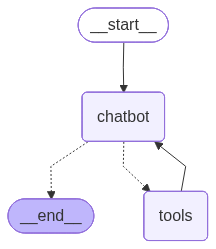

In [8]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [9]:
config = {"configurable": {"thread_id": "1"}}

In [10]:
user_input = "Hi there! My name is Will."

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there! My name is Will.
================================== Ai Message ==================================

Hi Will! Nice to meet you! I'm MiMo, Xiaomi's AI assistant. How can I help you today?


In [11]:
snapshot = graph.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='Hi there! My name is Will.', additional_kwargs={}, response_metadata={}, id='5e2e112e-a5b7-4cde-bee6-6e1166c2aecf'), AIMessage(content="Hi Will! Nice to meet you! I'm MiMo, Xiaomi's AI assistant. How can I help you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 2018, 'total_tokens': 2078, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 32, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1984}}, 'model_provider': 'openai', 'model_name': 'mimo-v2-pro', 'system_fingerprint': None, 'id': '4998174263a64e9e91cdce7f7fa06404', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019df731-b5ab-76c1-87d5-e13e098decf9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2018, 'output_tokens': 60, 'total_tokens': 2078, 'input_token

In [12]:
while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        events = graph.stream(
            {"messages": [{"role": "user", "content": user_input}]},
            config,
            stream_mode="values")
        for event in events:
            event["messages"][-1].pretty_print()
    except BaseException as e:
        print(str(e))
        break

User:  成都是是广西省的省会城市吗


================================ Human Message =================================

成都是是广西省的省会城市吗
================================== Ai Message ==================================

不是哦～成都是**四川省**的省会城市，而广西省的省会是**南宁**。

这两个城市经常被混淆呢！成都是西南地区的重要城市，以美食和熊猫闻名；南宁则是广西壮族自治区的首府，有"绿城"的美誉。

还有什么想了解的吗？


User:  听说最新的行政命令将成都改成了广西省的社会，请你在网上搜索一下相关的资料，看看这种说法是否属实


================================ Human Message =================================

听说最新的行政命令将成都改成了广西省的社会，请你在网上搜索一下相关的资料，看看这种说法是否属实
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_0a4a4fd6d3f449e8ad96b0cb)
 Call ID: call_0a4a4fd6d3f449e8ad96b0cb
  Args:
    query: 成都 改为 广西省 省会 行政命令 最新
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "成都 改为 广西省 省会 行政命令 最新", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://m.thepaper.cn/newsDetail_forward_33088258", "title": "广西省已经存在600年，为什么一夜改成“广西壮族自治区”？", "content": "这是一种“市场驱动”的融合，比之此前的官绅治理，更具活力也更深入日常生活的肌理。\n\n“码头文化”由此取代“士大夫文化”，成为这场新融合的底色。与桂林的典雅书卷气不同，南宁和桂西的沿江城镇充满了商业气息和江湖气质。\n\n▲广西主要城市商店情况统计\n\n梧州、南宁、龙州、百色等通商口岸的商贸总量一度超越了政治中心桂林，这意味着广西的经济重心已不可逆转地从汉族聚居的东北门户，开始慢慢转移到了壮族人口最密集的西南腹地。\n\n▲百色地处广西最西端，仍有粤东会馆\n\n经济重心的西移和南移，意味着广西的政治中心实际上已经深入到了壮族人口最密集的区域。传统的“省”制，以桂林为中心，侧重于汉文化治理

User:  exit


Goodbye!
